In [ ]:
import tensorflow as tf
import os
import numpy as np
import glob

In [ ]:
images = sorted(glob.glob('/content/drive/MyDrive/Dataset for flood Segmenttaion/Image/*.jpg'))
masks = sorted(glob.glob('/content/drive/MyDrive/Dataset for flood Segmenttaion/Mask/*.png'))

len(images), len(masks)

(290, 290)

In [ ]:
import cv2
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Custom data generator

In [ ]:
class CustomDataGenerator(keras.utils.Sequence):
    def __init__(self, images, masks, batch_size=8, img_size=(512, 512), shuffle=True):
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.images = images #os.listdir(image_folder)
        self.masks = masks #os.listdir(mask_folder)

        # on each epoch end, shuffle the dataset
        self.on_epoch_end()

        # datagen function to augment the input image and mask pair
        self.datagen = ImageDataGenerator(
            rotation_range=5,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.05,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode = 'constant',
            cval=0.0,
        )

    # randomly crop the images to 512x512 size
    def random_crop(self, image, mask, crop_size=512):

        # image width and height calculation
        img_height, img_width = image.shape[0], image.shape[1]
        mask_height, mask_width = mask.shape[0], mask.shape[1]

        # random x and y coordinate for cropping the image
        x = np.random.randint(0, img_width - crop_size)
        y = np.random.randint(0, img_height - crop_size)

        # random crop
        image_crop = image[y:y + crop_size, x:x + crop_size, :]
        mask_crop = mask[y:y + crop_size, x:x + crop_size]

        return image_crop, mask_crop

    # data augmentation using keras ImageDataGenerator function
    def data_augmentation(self, image, mask):
        trans_param = self.datagen.get_random_transform(image.shape)
        image = self.datagen.apply_transform(image, trans_param)
        mask = self.datagen.apply_transform(mask, trans_param)
        return image, mask

    # length of the processing batch
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    # data normalization
    def data_normalization(self, image, mask):

        # reshape mask from 512x512 to 512x512x1
        mask = mask.reshape((*self.img_size, 1))

        # Binary mask
        mask = np.where(mask<127, 0, 1)

        # data normalization (If you want to normalize another way, change the below line)
        image = image / 255.0

        # return image and mask
        return image, mask

    # data preprocessing, resize, crop image etc
    def data_preprocessing(self, image, mask):
        image, mask = cv2.resize(image, (576, 576)), cv2.resize(mask, (576, 576))
        image, mask = self.random_crop(image, mask)
        return image, mask

    # on each epoch, shuffle the dataset (image and mask index)
    def on_epoch_end(self):
        self.indexes = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    # get item is the core function
    # this function will run in each batch/epoch to load the dataset into RAM and pass to DL model
    def __getitem__(self, index):

        # start and end index
        # the last index can be shorter than the number of batches
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.images))
        indexes = self.indexes[start_idx:end_idx]

        # initialize the images and mask batches
        batch_images = []
        batch_masks = []

        # iterate over each indexes in batch
        for i in indexes:
            img_path = self.images[i]
            mask_path = self.masks[i]

            # read image using open cv
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            # Skip if image or mask is not loaded properly
            if img is None or mask is None:
                continue

            # image preprocessing; resize, random crop
            img, mask = self.data_preprocessing(img, mask)

            # data normalization
            img, mask = self.data_normalization(img, mask)

            # data augmentation
            img, mask = self.data_augmentation(img, mask)

            # to fix the issue during training process
            mask = mask.astype(np.float32)

            # append each image, mask pair to the batches
            batch_images.append(img)
            batch_masks.append(mask)

        # return batch image and batch mamks as a numpy array (n, tile_x, tile_y, channels)
        return np.array(batch_images), np.array(batch_masks)

## Testing and visualization of image/mask pair

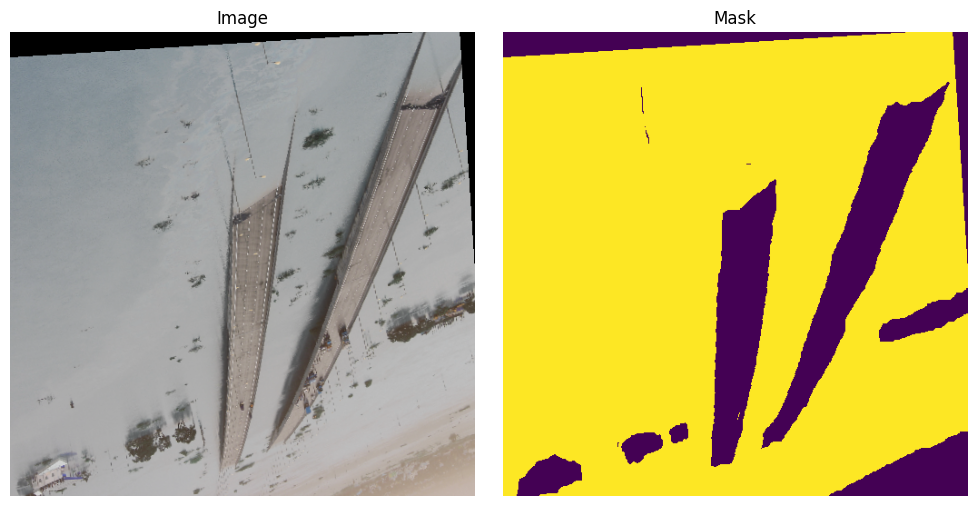

In [ ]:
import matplotlib.pyplot as plt

data = CustomDataGenerator(images, masks)
batch_images, batch_masks = data.__getitem__(0)

img = np.random.randint(0,8)
# Visualize the first image and its mask from the batch
image = batch_images[img]
mask = batch_masks[img]

# Plotting the image and its mask
plt.figure(figsize=(10, 5))

# Display Image
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Image')
plt.axis('off')

# Display Mask
plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title('Mask')
plt.axis('off')

plt.tight_layout()
plt.show()




## Train and test dataset split

In [ ]:
from sklearn.model_selection import train_test_split
train_img, test_img, train_mask, test_mask = train_test_split(images, masks, test_size=0.2, random_state=42)

In [ ]:
len(train_img), len(test_img)

(232, 58)

In [ ]:
train_dataset = CustomDataGenerator(train_img, train_mask)
test_dataset = CustomDataGenerator(test_img, test_mask)

## Custom metrics

1. Precision
2. Recall
3. F1-Score
4. Dice loss

## Custom loss function

Instead of default loss function (`binary_crossentropy`), you can use the `dice_loss` function implemented below as well.

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

# recall
def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

# precision
def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

#f1 score
def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

def dsc(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    return score

def dice_loss(y_true, y_pred):
    loss = 1 - dsc(y_true, y_pred)
    return loss

In [ ]:
# weighted binary crosstropy function
def weighted_binary_crossentropy(y_true, y_pred, weights=[0.5, 0.5]):
    # Calculate weighted binary cross-entropy loss
    class_weighted_loss = BinaryCrossentropy(from_logits=True)
    loss = class_weighted_loss(y_true, y_pred)

    # Calculate class weights for each pixel in the mask
    weights = (1.0 - y_true) * weights[0] + y_true * weights[1]

    # Apply the class weights to the loss for each pixel
    weighted_loss = loss * weights

    # Compute the mean loss over all pixels
    return K.mean(weighted_loss)

## Attention unet

In [ ]:
# Wrapper function to switch between different loss functions
loss_functions = ['dice_loss', 'binary_crossentropy', 'wbcdl', 'focal_loss']
def get_loss_function(loss_name):
    if loss_name == 'dice_loss':
        return dice_loss
    elif loss_name == 'binary_crossentropy':
        return 'binary_crossentropy'
    elif loss_name == 'focal_loss':
        return BinaryFocalLoss(2.0)
    elif loss_name == 'wbcdl':
      return weighted_binary_crossentropy
    else:
        raise ValueError('Invalid loss function name')


activations = ['relu', 'lru']
def get_activation_function(activation):
  if activation == 'relu':
    return 'relu'
  elif activation == 'lru':
    return LeakyReLU()
  else:
    raise ValueError("Invalid activation function name!")

In [ ]:
!pip install focal-loss

In [ ]:
import tensorflow as tf

from tensorflow.keras import backend as K
from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.losses import *
from focal_loss import BinaryFocalLoss
# from utils.utils import f1_m, precision_m, recall_m, dsc

from sklearn.metrics import *

def expend_as(tensor, rep,name):
	my_repeat = Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3), arguments={'repnum': rep},  name='psi_up'+name)(tensor)
	return my_repeat


def AttnGatingBlock(x, g, inter_shape, activation, name):
    ''' take g which is the spatially smaller signal, do a conv to get the same
    number of feature channels as x (bigger spatially)
    do a conv on x to also get same geature channels (theta_x)
    then, upsample g to be same size as x
    add x and g (concat_xg)
    relu, 1x1 conv, then sigmoid then upsample the final - this gives us attn coefficients'''

    shape_x = K.int_shape(x)  # 32
    shape_g = K.int_shape(g)  # 16

    theta_x = Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same', name='xl'+name)(x)  # 16
    shape_theta_x = K.int_shape(theta_x)

    phi_g = Conv2D(inter_shape, (1, 1), padding='same')(g)
    upsample_g = Conv2DTranspose(inter_shape, (3, 3),strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),padding='same', name='g_up'+name)(phi_g)  # 16

    concat_xg = add([upsample_g, theta_x])
    act_xg = Activation(activation)(concat_xg)
    psi = Conv2D(1, (1, 1), padding='same', name='psi'+name)(act_xg)
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)
    upsample_psi = UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)  # 32

    upsample_psi = expend_as(upsample_psi, shape_x[3],  name)
    y = multiply([upsample_psi, x], name='q_attn'+name)

    result = Conv2D(shape_x[3], (1, 1), padding='same',name='q_attn_conv'+name)(y)
    result_bn = BatchNormalization(name='q_attn_bn'+name)(result)
    return result_bn

def UnetConv2D(input, outdim, is_batchnorm, activation, name):
	x = Conv2D(outdim, (3, 3), strides=(1, 1), kernel_initializer=kinit, padding="same", name=name+'_1')(input)
	if is_batchnorm:
		x =BatchNormalization(name=name + '_1_bn')(x)
	x = Activation(activation,name=name + '_1_act')(x)

	x = Conv2D(outdim, (3, 3), strides=(1, 1), kernel_initializer=kinit, padding="same", name=name+'_2')(x)
	if is_batchnorm:
		x = BatchNormalization(name=name + '_2_bn')(x)
	x = Activation(activation, name=name + '_2_act')(x)
	return x


def UnetGatingSignal(input, is_batchnorm, activation, name):
    ''' this is simply 1x1 convolution, bn, activation '''
    shape = K.int_shape(input)
    x = Conv2D(shape[3] * 1, (1, 1), strides=(1, 1), padding="same",  kernel_initializer=kinit, name=name + '_conv')(input)
    if is_batchnorm:
        x = BatchNormalization(name=name + '_bn')(x)
    x = Activation(activation, name = name + '_act')(x)
    return x

K.set_image_data_format('channels_last')  # TF dimension ordering in this code
kinit = 'glorot_normal'

def attn_unet(hp, pretrained_weights = None, input_size = (512,512,3)):

        # some hyperparameters
        filtersFirstLayer = hp.Choice('firstFilterLayer', [32,64,128])

        activation_func_name = hp.Choice('activations', activations)
        activation = get_activation_function(activation_func_name)

        is_batchnorm = hp.Boolean('is_batchnorm')
        lr = hp.Float('lr', min_value=0.0001, max_value=0.01, sampling='log')
        loss_func_name = hp.Choice('loss_func', loss_functions)
        loss_func = get_loss_function(loss_func_name)

        inputs = Input(shape=input_size)
        conv1 = UnetConv2D(inputs, filtersFirstLayer, is_batchnorm=is_batchnorm, activation=activation, name='conv1')
        pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

        conv2 = UnetConv2D(pool1, filtersFirstLayer, is_batchnorm=is_batchnorm, activation=activation, name='conv2')
        pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

        conv3 = UnetConv2D(pool2, filtersFirstLayer*2, is_batchnorm=is_batchnorm, activation=activation, name='conv3')
        #conv3 = Dropout(0.2,name='drop_conv3')(conv3)
        pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

        conv4 = UnetConv2D(pool3, filtersFirstLayer*2, is_batchnorm=is_batchnorm, activation=activation, name='conv4')
        #conv4 = Dropout(0.2, name='drop_conv4')(conv4)
        pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

        center = UnetConv2D(pool4, filtersFirstLayer*4, is_batchnorm=is_batchnorm, activation=activation, name='center')

        g1 = UnetGatingSignal(center, is_batchnorm=is_batchnorm, activation=activation, name='g1')
        attn1 = AttnGatingBlock(conv4, g1, filtersFirstLayer*4, activation, '_1')
        up1 = concatenate([Conv2DTranspose(filtersFirstLayer, (3,3), strides=(2,2), padding='same', activation=activation, kernel_initializer=kinit)(center), attn1], name='up1')

        g2 = UnetGatingSignal(up1, is_batchnorm=is_batchnorm, activation=activation, name='g2')
        attn2 = AttnGatingBlock(conv3, g2, filtersFirstLayer*2, activation, '_2')
        up2 = concatenate([Conv2DTranspose(filtersFirstLayer*2, (3,3), strides=(2,2), padding='same', activation=activation, kernel_initializer=kinit)(up1), attn2], name='up2')

        g3 = UnetGatingSignal(up1, is_batchnorm=is_batchnorm, activation=activation, name='g3')
        attn3 = AttnGatingBlock(conv2, g3, filtersFirstLayer, activation, '_3')
        up3 = concatenate([Conv2DTranspose(filtersFirstLayer, (3,3), strides=(2,2), padding='same', activation=activation, kernel_initializer=kinit)(up2), attn3], name='up3')

        up4 = concatenate([Conv2DTranspose(filtersFirstLayer, (3,3), strides=(2,2), padding='same', activation=activation, kernel_initializer=kinit)(up3), conv1], name='up4')
        conv10 = Conv2D(1, (1, 1), activation='sigmoid',  kernel_initializer=kinit, name='final')(up4)

        model = Model(inputs, conv10)

        model.compile(optimizer = Adam(learning_rate=lr), loss = loss_func, metrics = ['accuracy', f1_m, precision_m, recall_m, dsc])
        # model.summary()

        if(pretrained_weights):
            model.load_weights(pretrained_weights)

        return model


In [ ]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.5 MB/s eta 0:00:00


In [ ]:
import keras_tuner
model = attn_unet(keras_tuner.HyperParameters())

In [ ]:
# Initialize the tuner (e.g., RandomSearch)
tuner = keras_tuner.RandomSearch(
    attn_unet,
    objective=keras_tuner.Objective("val_f1_m", direction="max"),      # Define the metric to optimize
    max_trials=15,             # Number of hyperparameter combinations to try
    directory='/content/drive/MyDrive/dl/flood/kt',      # Directory to save the results
    project_name='flood_tuner' # Name for the project
)

Reloading Tuner from /content/drive/MyDrive/dl/flood/kt/flood_tuner/tuner0.json


In [ ]:
# Define training data and start the search
tuner.search(train_dataset, epochs=10, validation_data=test_dataset)

In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 5
firstFilterLayer (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
activations (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'lru'], 'ordered': False}
is_batchnorm (Boolean)
{'default': False, 'conditions': []}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
loss_func (Choice)
{'default': 'dice_loss', 'conditions': [], 'values': ['dice_loss', 'binary_crossentropy', 'wbcdl', 'focal_loss'], 'ordered': False}


In [ ]:
models = tuner.get_best_models(num_models=1)
best_model = models[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 146 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 512, 512,  │      3,584 │ input_layer[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1_act         │ (None, 512, 512,  │          0 │ conv1_1[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv2D)    │ (None, 512, 512,  │    147,584 │ conv1_1_act[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2_act         │ (None, 512, 512,  │          0 │ conv1_2[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv1_2_act[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1 (Conv2D)    │ (None, 256, 256,  │    147,584 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_1_act         │ (None, 256, 256,  │          0 │ conv2_1[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2 (Conv2D)    │ (None, 256, 256,  │    147,584 │ conv2_1_act[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_2_act         │ (None, 256, 256,  │          0 │ conv2_2[0][0]     │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2_2_act[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1 (Conv2D)    │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_1_act         │ (None, 128, 128,  │          0 │ conv3_1[0][0]     │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2 (Conv2D)    │ (None, 128, 128,  │    590,080 │ conv3_1_act[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3_2_act         │ (None, 128, 128,  │          0 │ conv3_2[0][0]     │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv3_2_act[0][0] │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4_1 (Conv2D)    │ (None, 64, 64,    │    590,080 │ max_pooling2d_2[

 Total params: 13,482,628 (51.43 MB)

 Trainable params: 13,481,348 (51.43 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [ ]:
tuner.results_summary()

Results summary
Results in /content/drive/MyDrive/dl/flood/kt/flood_tuner
Showing 10 best trials
Objective(name="val_f1_m", direction="max")

Trial 00 summary
Hyperparameters:
firstFilterLayer: 128
activations: lru
is_batchnorm: False
lr: 0.00019530131540517075
loss_func: binary_crossentropy
Score: 0.8131112456321716

Trial 02 summary
Hyperparameters:
firstFilterLayer: 128
activations: lru
is_batchnorm: False
lr: 0.00037968531738380315
loss_func: wbcdl
Score: 0.8049107193946838

Trial 12 summary
Hyperparameters:
firstFilterLayer: 64
activations: relu
is_batchnorm: False
lr: 0.000616046351694513
loss_func: binary_crossentropy
Score: 0.8015040159225464

Trial 01 summary
Hyperparameters:
firstFilterLayer: 64
activations: lru
is_batchnorm: False
lr: 0.000690732191713988
loss_func: dice_loss
Score: 0.7928912043571472

Trial 04 summary
Hyperparameters:
firstFilterLayer: 128
activations: lru
is_batchnorm: False
lr: 0.0004294714000812411
loss_func: focal_loss
Score: 0.7845267653465271

Trial 0

## Training model

In [ ]:

# callback functions
checkpointer = tf.keras.callbacks.ModelCheckpoint(f"/content/drive/MyDrive/dl/flood/flood_best.h5", monitor="val_f1_m", verbose=1, save_best_only=True, mode="max")
earlyStopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_m', patience=5, verbose=1, mode='max')

callbacks = [
    earlyStopping,
    checkpointer
    ]

# model training
history = model.fit(train_dataset,epochs=50,
                    verbose = 1,
                    # validation_split=0.15,
                    validation_data=test_dataset,
                    callbacks=callbacks)

# save the model weights at the end of the training process
model.save(f"/content/drive/MyDrive/dl/flood/flood_save.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5193 - dsc: 0.4446 - f1_m: 0.4688 - loss: 0.5554 - precision_m: 0.3963 - recall_m: 0.6533
Epoch 1: val_f1_m improved from -inf to 0.53401, saving model to /content/drive/MyDrive/dl/flood/flood_best.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 201s 6s/step - accuracy: 0.5200 - dsc: 0.4445 - f1_m: 0.4717 - loss: 0.5555 - precision_m: 0.3974 - recall_m: 0.6602 - val_accuracy: 0.3696 - val_dsc: 0.4512 - val_f1_m: 0.5340 - val_loss: 0.5477 - val_precision_m: 0.3667 - val_recall_m: 1.0000
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.6437 - dsc: 0.4967 - f1_m: 0.6411 - loss: 0.5033 - precision_m: 0.5032 - recall_m: 0.9148
Epoch 2: val_f1_m improved from 0.53401 to 0.57168, saving model to /content/drive/MyDrive/dl/flood/flood_best.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.6456 - dsc: 0.4982 - f1_m: 0.6425 - loss: 0.5018 - precision_m: 0.5052 - recall_m: 0.9145 - val_accuracy: 0.4525 - val_dsc: 0.5060 - val_f1_m: 0.5717 - val_loss: 0.4949 - val_precision_m: 0.4007 - val_recall_m: 0.9998
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.7988 - dsc: 0.6590 - f1_m: 0.7659 - loss: 0.3410 - precision_m: 0.6921 - recall_m: 0.8693
Epoch 3: val_f1_m improved from 0.57168 to 0.67761, saving model to /content/drive/MyDrive/dl/flood/flood_best.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.7990 - dsc: 0.6595 - f1_m: 0.7658 - loss: 0.3405 - precision_m: 0.6921 - recall_m: 0.8691 - val_accuracy: 0.6415 - val_dsc: 0.6096 - val_f1_m: 0.6776 - val_loss: 0.4028 - val_precision_m: 0.5282 - val_recall_m: 0.9694
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 941ms/step - accuracy: 0.8231 - dsc: 0.7275 - f1_m: 0.7719 - loss: 0.2725 - precision_m: 0.7251 - recall_m: 0.8346
Epoch 4: val_f1_m did not improve from 0.67761
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8232 - dsc: 0.7279 - f1_m: 0.7719 - loss: 0.2721 - precision_m: 0.7255 - recall_m: 0.8342 - val_accuracy: 0.6057 - val_dsc: 0.6194 - val_f1_m: 0.6385 - val_loss: 0.3768 - val_precision_m: 0.4798 - val_recall_m: 0.9846
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 942ms/step - accuracy: 0.8233 - dsc: 0.7605 - f1_m: 0.7763 - loss: 0.2395 - precision_m: 0.7411 - recall_m: 0.8224
Epoch 5: val_f1_m improved from 0.67761 to 0.68051, saving model to /content/drive/MyDrive/dl/flood

29/29 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8235 - dsc: 0.7604 - f1_m: 0.7763 - loss: 0.2396 - precision_m: 0.7411 - recall_m: 0.8224 - val_accuracy: 0.7032 - val_dsc: 0.6488 - val_f1_m: 0.6805 - val_loss: 0.3370 - val_precision_m: 0.5314 - val_recall_m: 0.9585
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.8336 - dsc: 0.7741 - f1_m: 0.7829 - loss: 0.2259 - precision_m: 0.7454 - recall_m: 0.8322
Epoch 6: val_f1_m improved from 0.68051 to 0.81951, saving model to /content/drive/MyDrive/dl/flood/flood_best.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8337 - dsc: 0.7742 - f1_m: 0.7830 - loss: 0.2258 - precision_m: 0.7456 - recall_m: 0.8320 - val_accuracy: 0.8569 - val_dsc: 0.7555 - val_f1_m: 0.8195 - val_loss: 0.2566 - val_precision_m: 0.7922 - val_recall_m: 0.8525
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.8409 - dsc: 0.7745 - f1_m: 0.7827 - loss: 0.2255 - precision_m: 0.7543 - recall_m: 0.8236
Epoch 7: val_f1_m did not improve from 0.81951
29/29 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8407 - dsc: 0.7746 - f1_m: 0.7827 - loss: 0.2254 - precision_m: 0.7546 - recall_m: 0.8233 - val_accuracy: 0.7415 - val_dsc: 0.5320 - val_f1_m: 0.5066 - val_loss: 0.4801 - val_precision_m: 0.9105 - val_recall_m: 0.3603
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.8440 - dsc: 0.8045 - f1_m: 0.8100 - loss: 0.1955 - precision_m: 0.7837 - recall_m: 0.8473
Epoch 8: val_f1_m did not improve from 0.81951
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0

## Model performance

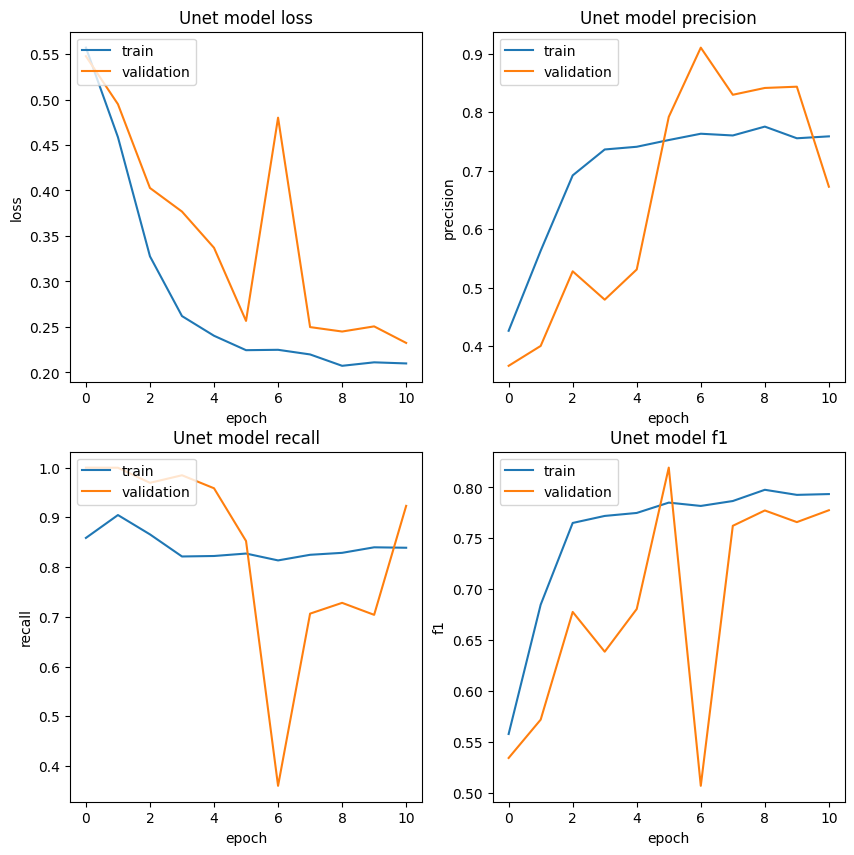

In [ ]:
fig,((ax11, ax12),(ax13,ax14)) = plt.subplots(2,2,figsize=(10,10))
ax11.plot(history.history['loss'])
ax11.plot(history.history['val_loss'])
ax11.title.set_text('Unet model loss')
ax11.set_ylabel('loss')
ax11.set_xlabel('epoch')
ax11.legend(['train', 'validation'], loc='upper left')

ax12.plot(history.history['precision_m'])
ax12.plot(history.history['val_precision_m'])
ax12.set_title('Unet model precision')
ax12.set_ylabel('precision')
ax12.set_xlabel('epoch')
ax12.legend(['train', 'validation'], loc='upper left')

ax13.plot(history.history['recall_m'])
ax13.plot(history.history['val_recall_m'])
ax13.set_title('Unet model recall')
ax13.set_ylabel('recall')
ax13.set_xlabel('epoch')
ax13.legend(['train', 'validation'], loc='upper left')

ax14.plot(history.history['f1_m'])
ax14.plot(history.history['val_f1_m'])
ax14.set_title('Unet model f1')
ax14.set_ylabel('f1')
ax14.set_xlabel('epoch')
ax14.legend(['train', 'validation'], loc='upper left')